In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Perceptron

from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve, precision_recall_fscore_support,
    matthews_corrcoef
)
from collections import Counter

In [16]:
df = pd.read_csv("synthetic_fraud_dataset.csv")

cols_drop = ["Transaction_ID", "User_ID", "Timestamp"]
df_base = df.drop(columns=[c for c in cols_drop if c in df.columns]).copy()

if "Fraud_Label" in df_base.columns:
    y_col = "Fraud_Label"
else:
    raise ValueError("Fraud_Label no encontrada en el dataset.")

print("Usando y_col:", y_col)

X = df_base.drop(columns=[y_col])
y = df_base[y_col]

Usando y_col: Fraud_Label


In [17]:
if y.dtype == 'O' or str(y.dtype).startswith('category') or y.dtype == bool:
    y_lower = y.astype(str).str.lower()

    mappings = [
        {"yes":1, "no":0},
        {"si":1, "no":0},
        {"true":1, "false":0},
        {"fraud":1, "not_fraud":0},
        {"1":1, "0":0}
    ]

    mapped = None
    for m in mappings:
        if set(y_lower.unique()).issubset(m.keys()):
            mapped = y_lower.map(m)

    if mapped is not None:
        y = mapped.astype(int)
        print("Se mapeó y a {0,1}.")

In [18]:
num_cols = X.select_dtypes(include=['number']).columns.tolist()
cat_cols = X.select_dtypes(exclude=['number']).columns.tolist()

print("Cantidad de variables numéricas:", len(num_cols))
print("Cantidad de variables categóricas:", len(cat_cols))

Cantidad de variables numéricas: 11
Cantidad de variables categóricas: 6


In [19]:
mask = ~pd.isna(y)
X = X.loc[mask].reset_index(drop=True)
y = y.loc[mask].reset_index(drop=True)

In [20]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

try:
    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])
except TypeError:
    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

preprocess = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols)
])

In [21]:
perc = Perceptron(
    penalty=None,
    alpha=0.0001,
    max_iter=1000,
    tol=1e-3,
    shuffle=True,
    eta0=0.1,
    random_state=42
)

pipe = Pipeline([
    ("prep", preprocess),
    ("clf", perc)
])

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nMatriz de confusión:\n", confusion_matrix(y_test, y_pred))
print("\nReporte de clasificación:\n", classification_report(y_test, y_pred))

NameError: name 'X_train' is not defined

In [10]:
print("\nVariable objetivo analizada:", y_col)
print(f"Tamaño train: {len(y_train)}  | test: {len(y_test)}")


Variable objetivo analizada: Fraud_Label
Tamaño train: 35000  | test: 15000


In [11]:
def distribucion(y, nombre):
    print(f"\nDistribución de clases en {nombre}:")
    c = Counter(y)
    for k,v in c.items():
        print(f"Clase {k}: {v} ({v/len(y):.2%})")

distribucion(y_train, "TRAIN")
distribucion(y_test, "TEST")


Distribución de clases en TRAIN:
Clase 0: 23753 (67.87%)
Clase 1: 11247 (32.13%)

Distribución de clases en TEST:
Clase 0: 10180 (67.87%)
Clase 1: 4820 (32.13%)


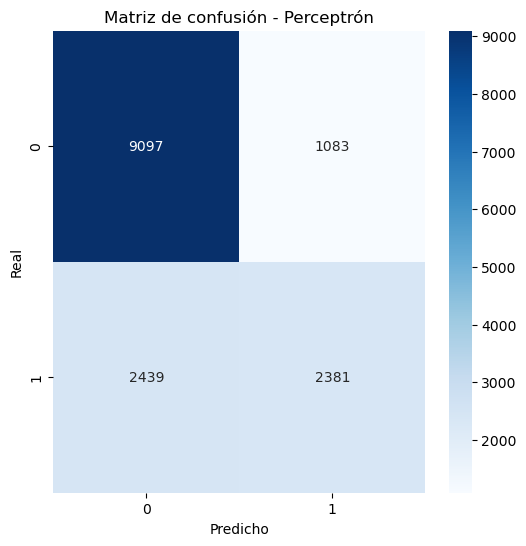

In [12]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de confusión - Perceptrón")
plt.show()

In [13]:
metrics = {}

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

metrics["Accuracy"] = accuracy_score(y_test, y_pred)
metrics["Precision"], metrics["Recall"], metrics["F1"], _ = precision_recall_fscore_support(
    y_test, y_pred, average="binary"
)
metrics["MCC"] = matthews_corrcoef(y_test, y_pred)

try:
    scores = pipe.decision_function(X_test)
    metrics["AUC"] = roc_auc_score(y_test, scores)
except:
    metrics["AUC"] = None

pd.DataFrame(metrics, index=["Perceptron"])

,Accuracy,Precision,Recall,F1,MCC,AUC
Perceptron,0.7652,0.687356,0.493983,0.574843,0.4295,0.821627


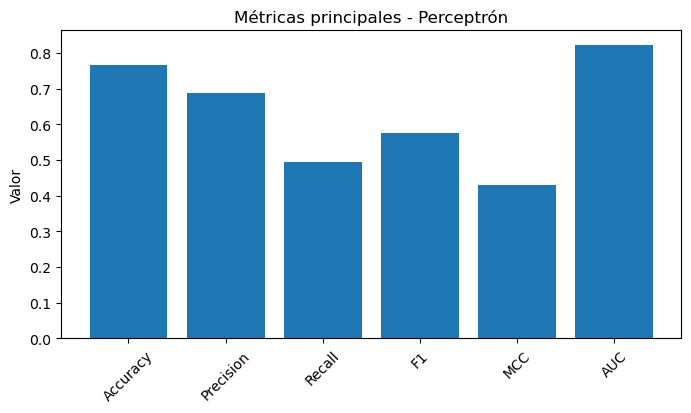

In [14]:
plt.figure(figsize=(8,4))
plt.bar(metrics.keys(), metrics.values())
plt.title("Métricas principales - Perceptrón")
plt.xticks(rotation=45)
plt.ylabel("Valor")
plt.show()

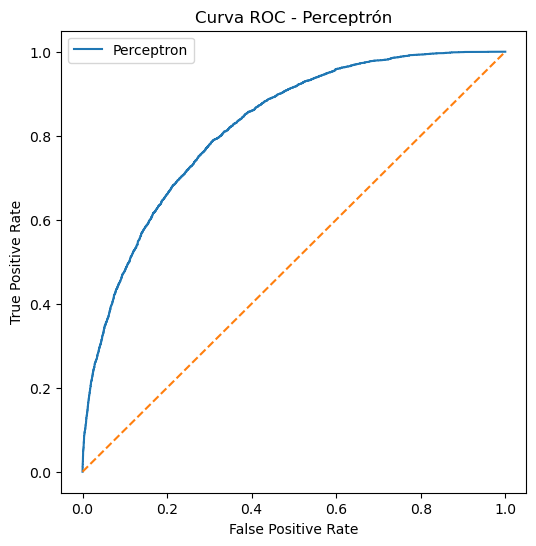

In [15]:
scores = pipe.decision_function(X_test)
fpr, tpr, _ = roc_curve(y_test, scores)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label="Perceptron")
plt.plot([0,1], [0,1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Perceptrón")
plt.legend()
plt.show()